In [1]:
import sys
sys.path.append("..")

import pandas as pd

from src.trading_strategy import compute_spread, compute_rolling_z, generate_signals
from src.pair_selection import find_correlated_pairs, find_cointegrated_pairs
import src.backtest as bt

## Load the Processed Price Dataset

In [2]:
adj_close_df = pd.read_csv("../data/processed/adj_close_prices.csv", index_col=0, parse_dates=True)

## Compute Cointegrated Pairs

- Rank them in order of smallest to highest p value.
- Then backtest using the best pair (smallest p value) first before doing it on multiple pairs.

In [3]:
correlated_pairs = find_correlated_pairs(adj_close_df, 0.7)
cointegrated_pairs = find_cointegrated_pairs(adj_close_df, correlated_pairs, 0.05)
cointegrated_pairs.sort(key = lambda x: x[3])

In [4]:
first_pair = cointegrated_pairs[0]
print(first_pair)

('JBLU', 'LUV', np.float64(0.9504446769104575), np.float64(7.109656764761808e-05))


In [5]:
first_pair_alpha, first_pair_beta, first_pair_spread = compute_spread(adj_close_df, first_pair)
first_pair_rolling_z = compute_rolling_z(first_pair_spread, 60)
first_pair_signals = generate_signals(first_pair_rolling_z)
print(first_pair_signals[1000:1100])

Date
2020-12-22   -1
2020-12-23   -1
2020-12-24   -1
2020-12-28   -1
2020-12-29   -1
             ..
2021-05-11   -1
2021-05-12    0
2021-05-13    0
2021-05-14    0
2021-05-17    0
Length: 100, dtype: int64


## Position Sizing

- To translate our directional signals into an actual trade, we size each position to be beta-neutral: the dollar amount allocated to each stock reflects the hedge ratio (beta) from our regression, so that price movements in one stock are proportionally offset by the other. 
- This isolates the strategy's returns to the spread's mean-reversion rather than general market movement.

## Calculating Daily PnL

- For each day we hold a position, profit/loss is calculated from the price change in each stock multiplied by the number of shares held (fixed at entry), with direction determined by the signal (long or short the spread). 
- Days with no position have zero PnL. Summing daily PnL over time gives our cumulative equity curve.

In [6]:
capital = 10000
trade_cost_rate = 0.001
first_pair_daily_pnl = bt.calculate_daily_pnl(adj_close_df, capital, trade_cost_rate, first_pair, first_pair_signals, first_pair_beta) 
print(first_pair_daily_pnl[1000:1100])

Date
2020-12-22   -117.819511
2020-12-23    140.721444
2020-12-24     20.829151
2020-12-28    178.637074
2020-12-29    -59.100019
                 ...    
2021-05-11     31.806398
2021-05-12    -11.639830
2021-05-13      0.000000
2021-05-14      0.000000
2021-05-17      0.000000
Length: 100, dtype: float64


## Equity Curve

Plotting cumulative PnL over time shows the strategy's overall performance. Despite periods of drawdown, the strategy shows an overall upward trend in profitability across the ~8 year backtest period.

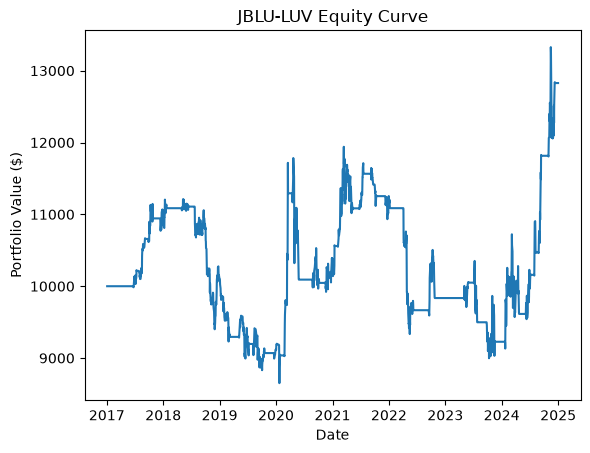

In [7]:
first_pair_daily_pnl_cumsum = first_pair_daily_pnl.cumsum()
bt.plot_equity_curve(capital, first_pair, first_pair_daily_pnl_cumsum, False)     

## Sharpe Ratio

The Sharpe ratio measures risk-adjusted return: average return per unit of volatility taken, nnualized using sqrt(252) trading days. Our strategy achieves a Sharpe of approximately 0.30, which is relatively
low (a Sharpe above 1 is generally considered decent). This likely reflects the strategy's basic entry/exit thresholds, lack of transaction cost modeling, and reliance on a single pair rather than a diversified portfolio of pairs — all areas for potential refinement.

In [8]:
first_pair_sharpe = bt.calculate_sharpe(capital, first_pair_daily_pnl)
print(first_pair_sharpe)

0.23937743901841346


## Maximum Drawdown

Maximum drawdown measures the largest peak-to-trough decline in the equity curve, capturing the worst-case loss an investor would have experienced. Our strategy has a max drawdown of approximately $2766, against a starting capital of $10,000 — a meaningful risk to consider alongside the modest Sharpe ratio.

In [9]:
first_pair_max_drawdown = bt.calculate_max_drawdown(first_pair_daily_pnl_cumsum)
print(first_pair_max_drawdown)    

2943.0744365533155


## CAGR (Compound Annual Growth Rate)

CAGR represents the annualized rate of return over the backtest period. Our strategy achieved a CAGR of approximately 3.9%, a modest return consistent with the low Sharpe ratio — suggesting there's room for improvement through refined entry/exit thresholds, transaction cost modeling, or trading a diversified portfolio of pairs rather than one.

In [10]:
first_pair_cagr = bt.calculate_cagr(adj_close_df, capital, first_pair_daily_pnl_cumsum)
print(first_pair_cagr)

0.031683133328014756


## Impact of Transaction Costs

Incorporating a 0.1% transaction cost when calculating daily PnL on both entry and exit reduces strategy performance, as expected. Sharpe ratio drops from ~0.30 to ~0.24, max drawdown increases from ~$2766 to ~$2943, and CAGR falls from ~3.9% to ~3.2%. This highlights the importance of accounting for 
real-world trading frictions — a strategy that looks reasonable on paper can be meaningfully less attractive once realistic costs are factored in, especially for strategies with frequent trading.

## Strategy vs Benchmark

We compare our strategy's equity curve to SPY (S&P 500 ETF), used here as a simple buy-and-hold benchmark. This confirms the strategy still significantly underperforms the benchmark on raw return, consistent with the Sharpe ratio and CAGR calculated above.

[*********************100%***********************]  1 of 1 completed


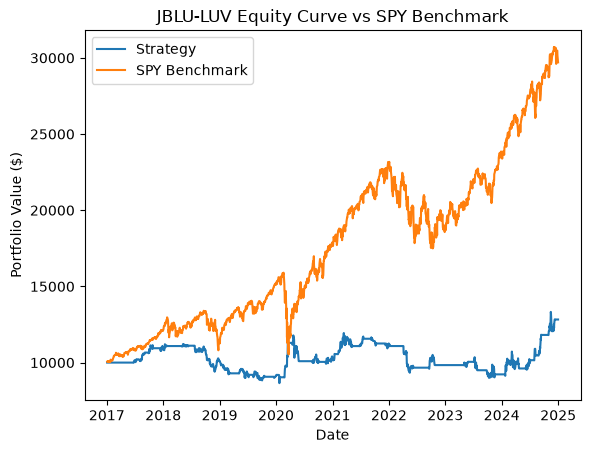

In [11]:
start_date = "2017-01-01"
end_date = "2025-01-01"
benchmark_ticker = "SPY"
spy_returns = bt.calculate_benchmark_returns(benchmark_ticker, start_date, end_date)
bt.plot_strategy_vs_benchmark(capital, first_pair_daily_pnl_cumsum, first_pair, benchmark_ticker, spy_returns, False)

## Correlation to Market Benchmark (SPY)

Despite underperforming SPY on raw return, our strategy's daily returns show almost no correlation with SPY (~-0.01). This supports the core premise of pairs trading as a market-neutral strategy — its performance is driven by the pair's relative mean-reversion rather than broader market direction, making it potentially valuable as a diversification tool rather than a standalone return-maximizing strategy.

In [12]:
strategy_returns = first_pair_daily_pnl_cumsum.diff() / capital
spy_returns = spy_returns.squeeze() 
correlation = strategy_returns.corr(spy_returns)
print(correlation)

-0.010764064122043008


[*********************100%***********************]  1 of 1 completed


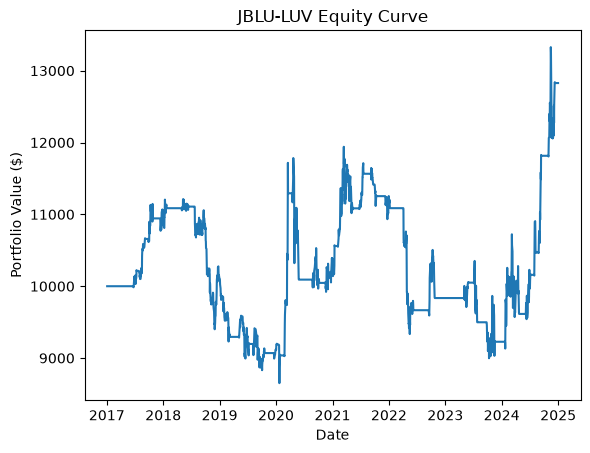

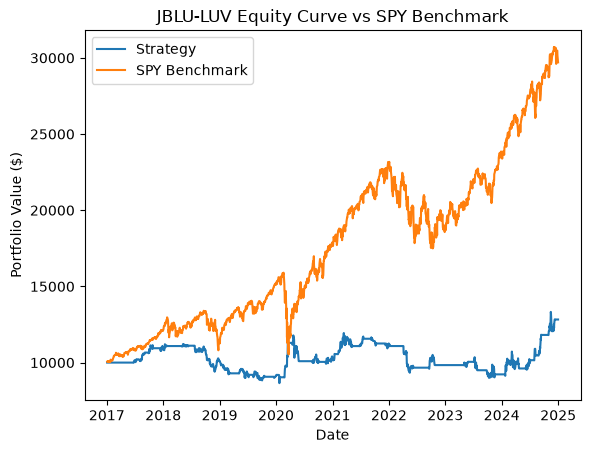

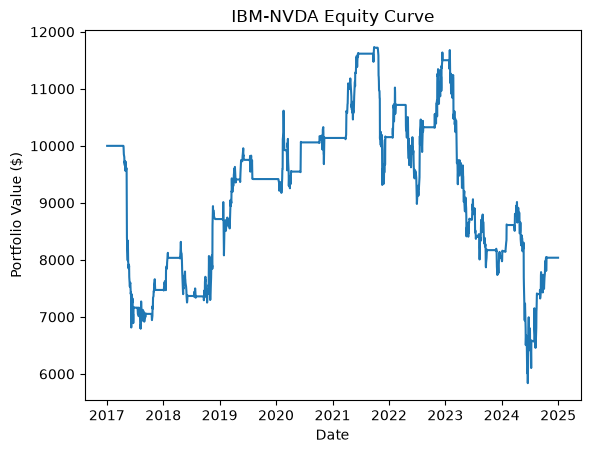

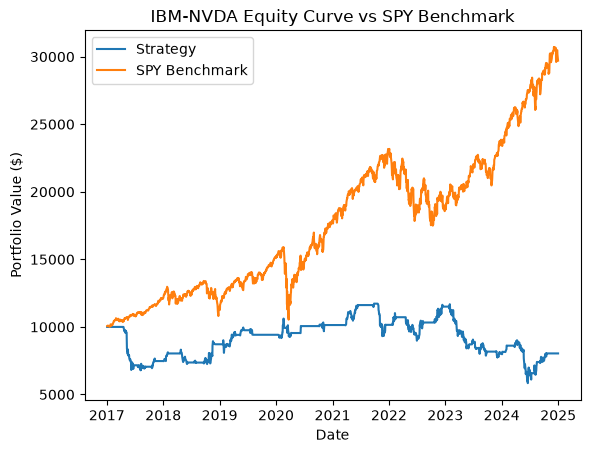

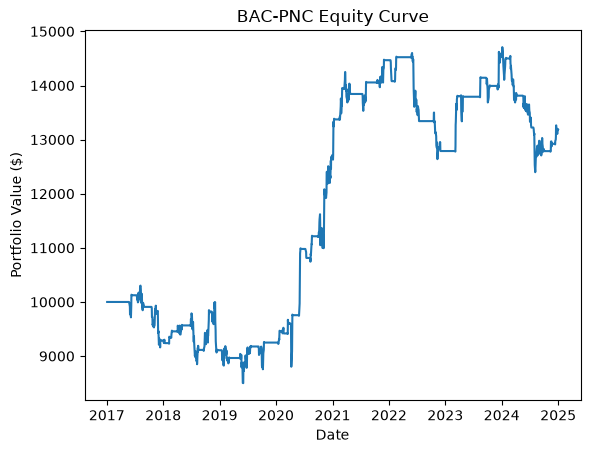

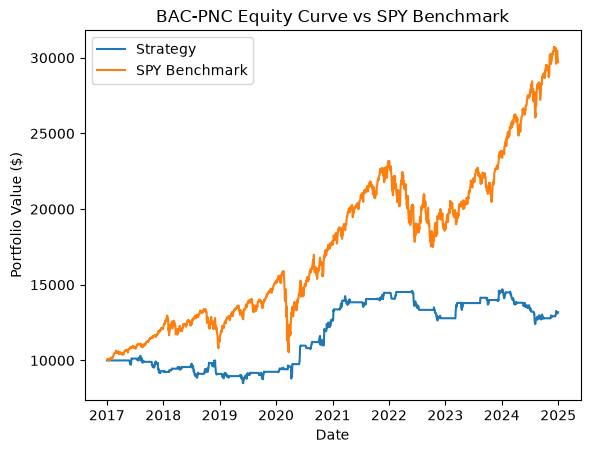

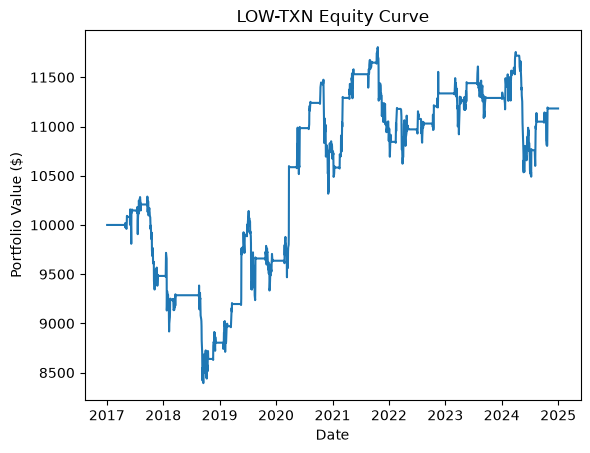

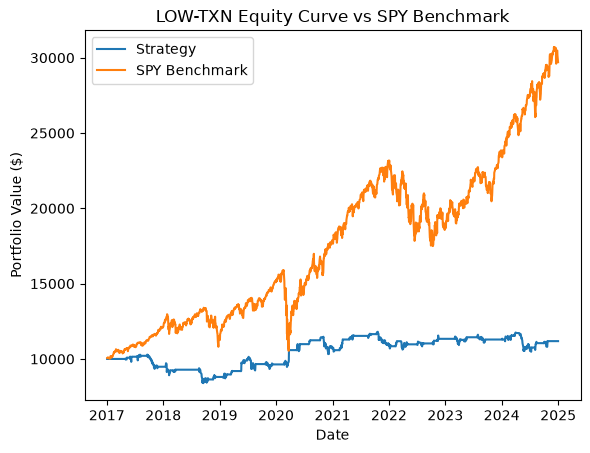

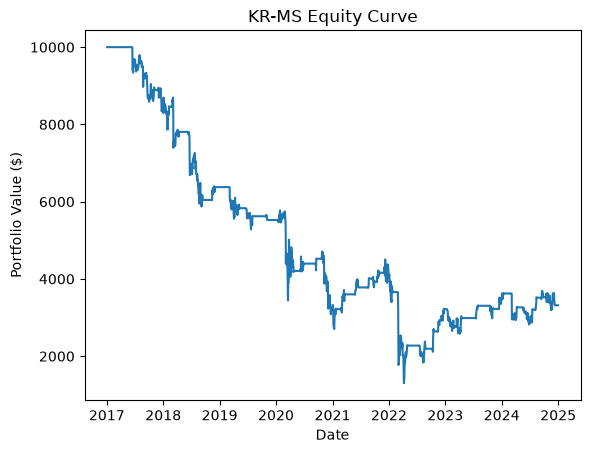

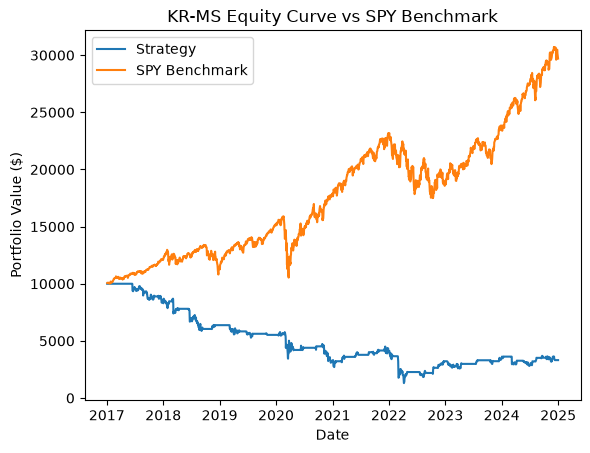

         pair  sharpe  max_drawdown    cagr
0     BAC-PNC   0.375       2310.77  0.0353
1    JBLU-LUV   0.239       2943.07  0.0317
2     COF-PNC   0.162       1200.89  0.0100
3     LOW-TXN   0.155       1894.71  0.0141
4       HD-KR   0.089       3412.15  0.0128
5    JPM-ORCL   0.066       2962.89  0.0059
6       HD-MS  -0.015       6054.45 -0.0020
7      C-SKYW  -0.019       2980.86 -0.0021
8      HD-TXN  -0.131       2751.29 -0.0134
9    IBM-NVDA  -0.145       5892.49 -0.0270
10     KR-LOW  -0.159       5103.83 -0.0276
11    AAPL-KR  -0.167       5263.66 -0.0324
12    BAC-COF  -0.299       4690.91 -0.0406
13   ADBE-BBY  -0.304       6420.77 -0.0674
14   ORCL-TJX  -0.314       3857.73 -0.0384
15    HD-MSFT  -0.329       2869.63 -0.0304
16  BAC-GOOGL  -0.351       5760.72 -0.0657
17   AAPL-LOW  -0.370       5248.77 -0.0416
18    JPM-WMT  -0.370       5110.88 -0.0499
19   GOOGL-HD  -0.394       5876.44 -0.0492
20    BBY-TGT  -0.409       6699.89 -0.0866
21   GOOGL-MS  -0.434       5413

In [13]:
capital = 10000
trade_cost_rate = 0.001

start_date = "2017-01-01"
end_date = "2025-01-01"
benchmark_ticker = "SPY"
num_plots = 5

metrics = bt.run_backtest(
        adj_close_df, 
        capital,
        trade_cost_rate,
        cointegrated_pairs,
        start_date,
        end_date,
        benchmark_ticker,
        num_plots,
        save_plots = False
    )

print(metrics)

## Conclusion

Backtesting all 25 cointegrated pairs reveals mixed results overall. Only 6 out of 25 pairs (24%) achieved a positive Sharpe ratio, with BAC-PNC performing best (Sharpe 0.375, CAGR 3.5%) and IBM-ORCL 
performing worst (Sharpe -0.661, CAGR -8.6%).

Notably, there is no clear relationship between a pair's cointegration p-value and its backtested performance — JBLU-LUV had by far the strongest statistical evidence of cointegration (p ≈ 0.00007) yet only ranked second by Sharpe, while several statistically significant pairs (e.g. IBM-ORCL, KR-MS) performed poorly. This suggests that while cointegration testing is a necessary filter for identifying candidate pairs, it does not guarantee profitable trading performance — the relationship's statistical significance in-sample doesn't necessarily persist or translate into a stable trading edge, especially with a fixed z-score threshold strategy and non-adaptive parameters.

Overall, the results highlight a common finding in quantitative finance: many statistically valid relationships are too weak, too slow to revert, or too costly (after transaction costs) to trade profitably in practice. Potential improvements include dynamic parameter tuning, portfolio-level diversification across pairs (to reduce the risk of any single failing pair), and stricter pair selection criteria beyond just p-value (e.g. requiring faster mean-reversion or higher spread 
volatility).